# High F-score vs random baskets — equal weight

Does picking the 30 highest F-score names each year beat picking 30 at random from the
same investable universe? Both arms are built identically — equal weight, `K` names,
formed 30/6, held twelve months, no leverage, no costs — so the only thing under test is
the ranking rule.

`N_SIM` random paths give the sampling distribution of each metric under "no skill"; the
strategy's metric is then read off as a percentile of it.

In [12]:
import portfolio_util as port_util
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

K, N_SIM = 25, 2000
SEEDS = {"f_rand": 20260810, "random": 20260811}   # keyed by ARM, not by weighting

## 1. Universe

`build_universe` screens **nothing** — whatever is passed in is the pool that *both* the
strategy and the null draw from, so the filter below defines the entire experiment. A row
is investable at formation only if it clears every gate at once:

| gate | meaning |
|---|---|
| `tradeable` | passed the 30-day pre-formation liquidity screen |
| `f_score` | all nine signals were scoreable |
| `bm` | book-to-market exists (implies shares and a December price) |
| `fwd_return_1y` | entry and exit prices found **and** the holding year has finished |

The last gate is what stops the panel at formation year 2025: a portfolio formed
30/6/2026 does not know its 30/6/2027 exit yet.

In [13]:
panel = pd.read_csv("../data/preprocessing_pipeline_results/final_panel.csv").set_index(["symbol", "period"])

investable = (panel["tradeable"].eq(True)
              & panel["f_score"].notna()
              & panel["bm"].notna()
              & panel["fwd_return_1y"].notna())
investable.value_counts()

False    12453
True      8780
Name: count, dtype: int64

In [14]:
universe = port_util.build_universe(panel[investable])
universe

Universe(T=14, years=2012-2025, rows=8,780, symbols=1,362)

In [15]:
# Names available each year — the pool both arms draw from.
universe.sizes().to_frame().T

formation_year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
n_names,329,416,430,473,515,553,542,586,690,878,844,857,859,808


## 2. The two arms

Both arms run through the same `build_portfolio` call and differ in exactly one flag:

| arm | ranking key | |
|---|---|---|
| `random` | uniform noise | the no-skill null |
| `f_rand` | `f_score` + uniform noise | the strategy |

`f_rand` is **also** 2,000 paths, not one. `f_score` is an integer 0-9, so a cut at K = 30
almost always lands inside a block of tied names — in 2023, all thirty slots come from the
34 names scoring 9. Breaking those ties at random and repeating makes the strategy a
distribution too, differing from the null in one respect only: the eligible pool.

Seeds are keyed by **arm**, not by weighting. Reusing them across notebooks makes the EW
and GMV portfolios share their selections exactly, which is what isolates construction
from selection.

In [16]:
null_ew = port_util.build_portfolio(universe, "random", k=K, weighting="ew",
                                    n_sim=N_SIM, seed=SEEDS["random"])
null_ew

Portfolio(arm='random', weighting='ew', k=25, n_paths=2000)

In [17]:
# The null distribution itself: one row per Monte-Carlo path.
null_ew.draws().describe().loc[["mean", "std", "min", "50%", "max"]]

,cagr,mean_ann,vol_ann,sharpe,mdd,wturn,effn,maxw
mean,0.148724,0.169779,0.244855,0.705324,-0.108821,0.965171,25.0,0.04
std,0.027178,0.030115,0.047617,0.126142,0.046205,0.009781,0.0,0.00
min,0.054045,0.070321,0.139364,0.343172,-0.368469,0.929231,25.0,0.04
50%,0.147736,0.168490,0.237459,0.692591,-0.106624,0.966154,25.0,0.04
max,0.259422,0.281295,0.473172,1.339413,0.000000,0.990769,25.0,0.04


In [18]:
f_ew = port_util.build_portfolio(universe, "f_rand", k=K, weighting="ew",
                                 n_sim=N_SIM, seed=SEEDS["f_rand"])
f_ew

Portfolio(arm='f_rand', weighting='ew', k=25, n_paths=2000)

## 3. Results

`metrics_table` collapses each path's 14 annual returns into one CAGR, one Sharpe, one
drawdown, then reads the strategy's mean against the null's 2,000-path distribution.
`z` is the standardised distance; `p_mc` is the Monte-Carlo p-value with the conservative
+1 correction.

`paired_test` asks a different question: differencing year by year removes the common
market effect, so it tests whether the *edge* is stable rather than whether the market
rose. With T = 14 non-overlapping annual observations it has little power — expect it to
be the weaker of the two, and report both.

Under equal weight `effn` and `maxw` are constants — 30 names and 1/30 apiece — so their
`z` is undefined by construction. They earn their place only once weights vary; see the
GMV notebook.

In [19]:
port_util.metrics_table(f_ew, null_ew).round(4)

,value,value_sd,null_mean,null_sd,null_p05,null_p95,z,p_mc,win_rate
metric,,,,,,,,,
cagr,0.2069,0.0142,0.1487,0.0272,0.1040,0.1950,2.1401,0.0230,0.9683
mean_ann,0.2257,0.0155,0.1698,0.0301,0.1211,0.2208,1.8555,0.0375,0.9466
vol_ann,0.2255,0.0189,0.2449,0.0476,0.1828,0.3368,-0.4074,0.3768,0.3822
sharpe,1.0046,0.0722,0.7053,0.1261,0.5195,0.9241,2.3723,0.0160,0.9746
mdd,-0.1153,0.0270,-0.1088,0.0462,-0.1879,-0.0390,-0.1396,0.5722,0.4409
wturn,0.8874,0.0106,0.9652,0.0098,0.9477,0.9815,-7.9545,0.0010,0.0000
effn,25.0000,0.0000,25.0000,0.0000,25.0000,25.0000,NaN,1.0000,0.0000
maxw,0.0400,0.0000,0.0400,0.0000,0.0400,0.0400,NaN,1.0000,0.0000


In [20]:
pd.DataFrame([port_util.paired_test(f_ew, null_ew, "f_rand - random (EW)")]).set_index("test").round(4)

,mean,sd,T,t,p_two_sided,p_one_sided,wins
test,,,,,,,
f_rand - random (EW),0.0559,0.1369,14,1.5271,0.1507,0.0753,10


## 4. Charts

`plot_null` draws the null histogram with the strategy marked; the pale band around the
red line is the strategy's **own** 5-95% spread, which matters because a random tiebreak
makes it a distribution too. A point outside the null means much less when its own spread
straddles the null.

`plot_equity` compounds the mean path against the null's band. The x axis is labelled by
**exit** year: equity at position `i` is what a portfolio formed in year `i` is worth once
its holding period closes.

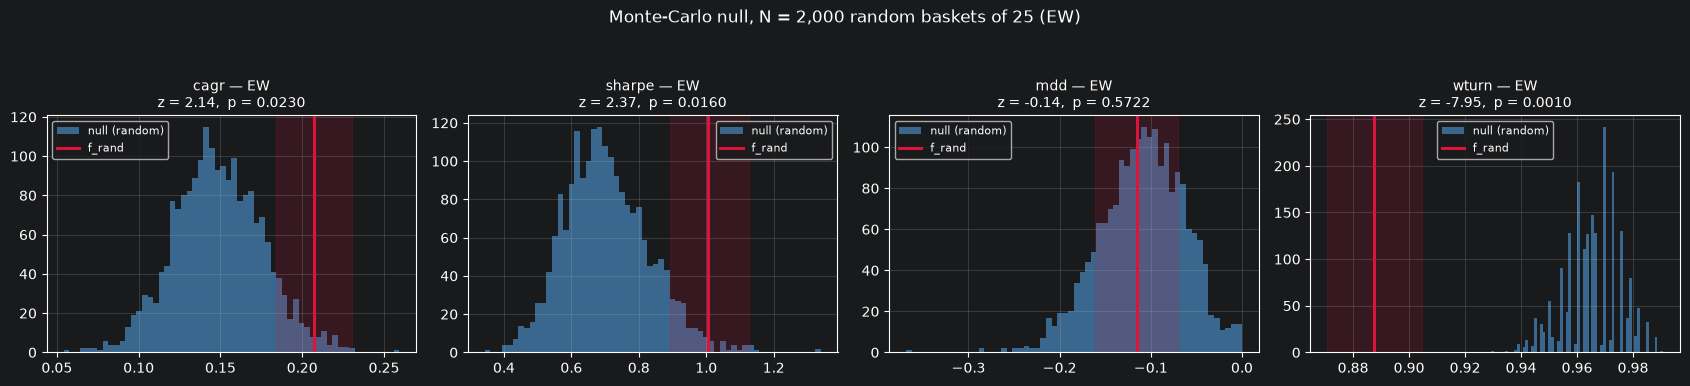

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, metric in zip(axes, ["cagr", "sharpe", "mdd", "wturn"]):
    port_util.plot_null(f_ew, null_ew, metric, ax=ax)
fig.suptitle(f"Monte-Carlo null, N = {N_SIM:,} random baskets of {K} (EW)", y=1.06)
fig.tight_layout()
plt.show()

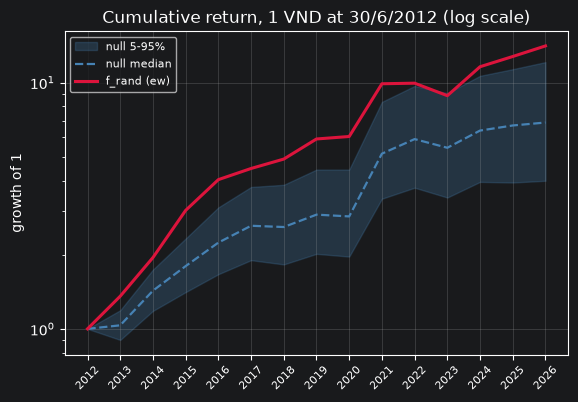

In [22]:
port_util.plot_equity(f_ew, null_ew)
plt.show()